Used cars price prediction

In [8]:
# best performing model to determine the price of the used car
# most important features determining the price

In [1]:
import pandas as pd
import numpy as np

In [99]:
df = pd.read_csv('Datasets/project dataset_dm9_lbv39rog/Dataset/cars.csv')
df

,Id,year,brand,full_model_name,model_name,price,distance_travelled(kms),fuel_type,city,brand_rank,car_age
0,0,2016,Honda,Honda Brio S MT,Brio,425000.0,9680.0,Petrol,Mumbai,7,5.0
1,1,2012,Nissan,Nissan Sunny XV Diesel,Sunny,325000.0,119120.0,Diesel,Mumbai,11,9.0
2,2,2017,Toyota,Toyota Fortuner 2.8 4x2 MT [2016-2020],Fortuner,2650000.0,64593.0,Diesel,Thane,1,4.0
3,3,2017,Mercedes-Benz,Mercedes-Benz E-Class E 220d Expression [2019-...,E-Class,4195000.0,25000.0,Diesel,Mumbai,2,4.0
4,4,2012,Hyundai,Hyundai Verna Fluidic 1.6 CRDi SX,Verna,475000.0,23800.0,Diesel,Mumbai,14,9.0
...,...,...,...,...,...,...,...,...,...,...,...
1720,1720,2015,Hyundai,Hyundai Eon Era +,Eon,290000.0,38000.0,Petrol,Pune,14,6.0
1721,1721,2011,Bentley,Bentley Continental Flying Spur W12,Continental,7500000.0,36000.0,Petrol,Pune,44,10.0
1722,1722,2008,Mahindra-Renault,Mahindra-Renault Logan DLE 1.5 dci,Logan,185000.0,142522.0,Diesel,Pune,24,13.0
1723,1723,1990,Mahindra,Mahindra Jeep CJ 500 D,Jeep,325000.0,18581.0,Diesel,Pune,24,31.0


In [3]:
df.isnull().sum()

Id                         0
year                       0
brand                      0
full_model_name            0
model_name                 0
price                      0
distance_travelled(kms)    0
fuel_type                  0
city                       0
brand_rank                 0
car_age                    0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()

,Id,year,price,distance_travelled(kms),brand_rank,car_age
count,1725.000000,1725.000000,1.725000e+03,1725.000000,1725.000000,1725.000000
mean,862.000000,2015.390725,1.494837e+06,53848.256232,15.731014,5.609275
std,498.108924,3.207504,1.671658e+06,44725.541963,12.951122,3.207504
min,0.000000,1990.000000,6.250000e+04,350.000000,1.000000,0.000000
25%,431.000000,2013.000000,5.450000e+05,29000.000000,5.000000,3.000000
50%,862.000000,2016.000000,8.750000e+05,49000.000000,14.000000,5.000000
75%,1293.000000,2018.000000,1.825000e+06,70500.000000,24.000000,8.000000
max,1724.000000,2021.000000,1.470000e+07,790000.000000,81.000000,31.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1725 entries, 0 to 1724
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Id                       1725 non-null   int64  
 1   year                     1725 non-null   int64  
 2   brand                    1725 non-null   object 
 3   full_model_name          1725 non-null   object 
 4   model_name               1725 non-null   object 
 5   price                    1725 non-null   float64
 6   distance_travelled(kms)  1725 non-null   float64
 7   fuel_type                1725 non-null   object 
 8   city                     1725 non-null   object 
 9   brand_rank               1725 non-null   int64  
 10  car_age                  1725 non-null   float64
dtypes: float64(3), int64(3), object(5)
memory usage: 148.4+ KB


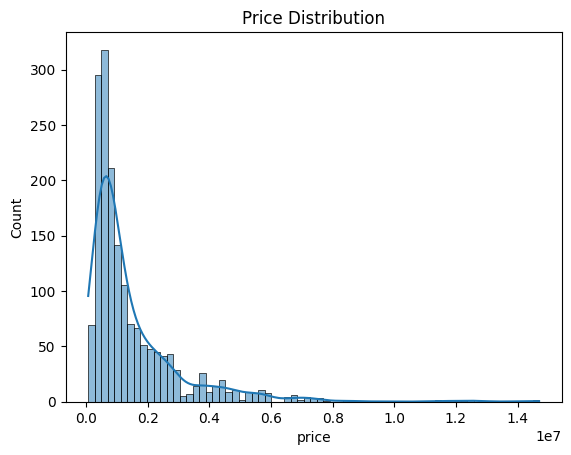

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

# univariate analysis

sns.histplot(df['price'], kde=True)
plt.title('Price Distribution')
plt.show()

In [11]:
df['fuel_type'].value_counts()

fuel_type
Diesel        922
Petrol        788
CNG + 1         8
Petrol + 1      6
Hybrid          1
Name: count, dtype: int64

In [15]:
df['brand'].nunique()

31

In [16]:
df['model_name'].nunique()

169

In [18]:
df['city'].value_counts()

city
Chennai        493
Bangalore      247
Pune           247
Hyderabad      245
Delhi          187
Mumbai         165
Dehradun        56
Thane           48
Noida           12
Ghaziabad       10
Lucknow          6
Navi Mumbai      5
Faridabad        2
Agra             1
Panchkula        1
Name: count, dtype: int64

In [22]:
df['city'].nunique()

15

In [19]:
df['full_model_name']

0                                         Honda Brio S MT
1                                  Nissan Sunny XV Diesel
2                  Toyota Fortuner 2.8 4x2 MT [2016-2020]
3       Mercedes-Benz E-Class E 220d Expression [2019-...
4                       Hyundai Verna Fluidic 1.6 CRDi SX
                              ...                        
1720                                    Hyundai Eon Era +
1721                  Bentley Continental Flying Spur W12
1722                   Mahindra-Renault Logan DLE 1.5 dci
1723                               Mahindra Jeep CJ 500 D
1724                    Hyundai Creta SX Plus 1.6 AT CRDI
Name: full_model_name, Length: 1725, dtype: object

In [21]:
df['full_model_name'].nunique()

750

In [85]:
df['brand_rank'].nunique()

29

In [101]:
print(np.array(df['brand'].unique()))
print(np.array(df['brand_rank'].unique()))

['Honda' 'Nissan' 'Toyota' 'Mercedes-Benz' 'Hyundai' 'Maruti Suzuki'
 'Renault' 'Volkswagen' 'Skoda' 'BMW' 'Tata' 'Audi' 'Bentley' 'Ford'
 'Mahindra' 'Jaguar' 'Lamborghini' 'MINI' 'Land Rover' 'Chevrolet'
 'Datsun' 'Jeep' 'Porsche' 'Volvo' 'MG' 'Lexus' 'Mitsubishi' 'Kia' 'Fiat'
 'Isuzu' 'Mahindra-Renault']
[ 7 11  1  2 14 32 15  3 27  4 40 10 44  8 24 45 39 18 12 50 19  5  9 81
 16 46 20 43 37]


In [84]:
df[['brand','brand_rank']].value_counts()

brand             brand_rank
Hyundai           14            297
Maruti Suzuki     32            275
Honda             7             153
Mercedes-Benz     2             131
Toyota            1             117
BMW               4             111
Audi              10             98
Mahindra          24             93
Ford              8              78
Volkswagen        3              70
Renault           15             51
Skoda             27             45
Tata              40             44
Jaguar            40             30
Land Rover        18             28
Volvo             9              17
Nissan            11             13
Kia               20             12
MG                81             10
Jeep              19             10
MINI              39             10
Chevrolet         12              9
Porsche           5               5
Mitsubishi        46              4
Bentley           44              3
Datsun            50              3
Fiat              43              2

In [102]:
df.columns

Index(['Id', 'year', 'brand', 'full_model_name', 'model_name', 'price',
       'distance_travelled(kms)', 'fuel_type', 'city', 'brand_rank',
       'car_age'],
      dtype='object')

In [92]:
df['model_name'].value_counts(normalize = True)

model_name
Creta     0.041159
Innova    0.040000
City      0.039420
Swift     0.033623
XUV500    0.026667
            ...   
Quanto    0.000580
Fabia     0.000580
Abarth    0.000580
Logan     0.000580
Jeep      0.000580
Name: proportion, Length: 169, dtype: float64

In [39]:
type(df[['city']])

pandas.core.frame.DataFrame

In [103]:
from sklearn.preprocessing import OneHotEncoder

# frequency encoding

# brand feature encoding not required as we also have brand_rank in the dataset
#brand_freq = df['brand'].value_counts(normalize = True)
#df['brand_freq'] = df['brand'].map(brand_freq)

model_name_freq = df['model_name'].value_counts(normalize=True)
df['model_name_freq'] = df['model_name'].map(model_name_freq)

city_freq = df['city'].value_counts(normalize=True)
df['city_freq'] = df['city'].map(city_freq)

# one hot encoding 

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')
fuel_type_encoded = encoder.fit_transform(df[['fuel_type']])
df = pd.concat([df,fuel_type_encoded], axis=1)

In [104]:
df['city_freq']

0       0.095652
1       0.095652
2       0.027826
3       0.095652
4       0.095652
          ...   
1720    0.143188
1721    0.143188
1722    0.143188
1723    0.143188
1724    0.143188
Name: city_freq, Length: 1725, dtype: float64

In [97]:
model_name_freq

model_name
Creta     0.041159
Innova    0.040000
City      0.039420
Swift     0.033623
XUV500    0.026667
            ...   
Quanto    0.000580
Fabia     0.000580
Abarth    0.000580
Logan     0.000580
Jeep      0.000580
Name: proportion, Length: 169, dtype: float64

In [105]:
df.columns

Index(['Id', 'year', 'brand', 'full_model_name', 'model_name', 'price',
       'distance_travelled(kms)', 'fuel_type', 'city', 'brand_rank', 'car_age',
       'model_name_freq', 'city_freq', 'fuel_type_CNG + 1', 'fuel_type_Diesel',
       'fuel_type_Hybrid', 'fuel_type_Petrol', 'fuel_type_Petrol + 1'],
      dtype='object')

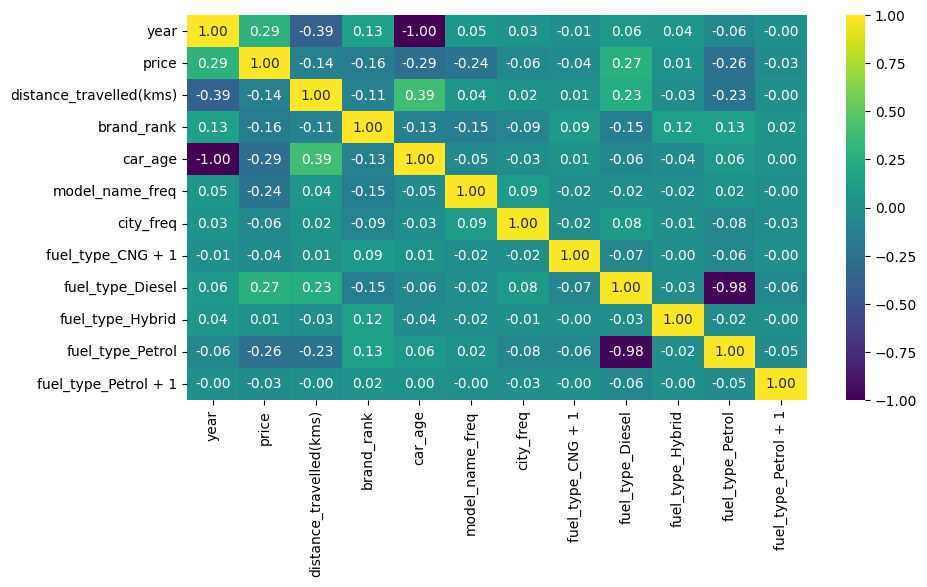

In [106]:
# correlation

# multivariate analysis

corr = df.drop(columns=['brand','full_model_name','city','model_name','Id','fuel_type']).corr()

plt.figure(figsize=(10,5))
sns.heatmap(corr,cmap='viridis', annot=True, fmt='.2f')
plt.show()

# corr might not capture encoded features linearity

In [107]:
print(corr[(corr >= 0.75) & (corr != 1.00)].sum())

corr[(corr >= 0.5) & (corr < 0.75)].sum()

year                       0.0
price                      0.0
distance_travelled(kms)    0.0
brand_rank                 0.0
car_age                    0.0
model_name_freq            0.0
city_freq                  0.0
fuel_type_CNG + 1          0.0
fuel_type_Diesel           0.0
fuel_type_Hybrid           0.0
fuel_type_Petrol           0.0
fuel_type_Petrol + 1       0.0
dtype: float64


year                       0.0
price                      0.0
distance_travelled(kms)    0.0
brand_rank                 0.0
car_age                    0.0
model_name_freq            0.0
city_freq                  0.0
fuel_type_CNG + 1          0.0
fuel_type_Diesel           0.0
fuel_type_Hybrid           0.0
fuel_type_Petrol           0.0
fuel_type_Petrol + 1       0.0
dtype: float64

In [108]:
df.head()

,Id,year,brand,full_model_name,model_name,price,distance_travelled(kms),fuel_type,city,brand_rank,car_age,model_name_freq,city_freq,fuel_type_CNG + 1,fuel_type_Diesel,fuel_type_Hybrid,fuel_type_Petrol,fuel_type_Petrol + 1
0,0,2016,Honda,Honda Brio S MT,Brio,425000.0,9680.0,Petrol,Mumbai,7,5.0,0.008116,0.095652,0.0,0.0,0.0,1.0,0.0
1,1,2012,Nissan,Nissan Sunny XV Diesel,Sunny,325000.0,119120.0,Diesel,Mumbai,11,9.0,0.002319,0.095652,0.0,1.0,0.0,0.0,0.0
2,2,2017,Toyota,Toyota Fortuner 2.8 4x2 MT [2016-2020],Fortuner,2650000.0,64593.0,Diesel,Thane,1,4.0,0.010435,0.027826,0.0,1.0,0.0,0.0,0.0
3,3,2017,Mercedes-Benz,Mercedes-Benz E-Class E 220d Expression [2019-...,E-Class,4195000.0,25000.0,Diesel,Mumbai,2,4.0,0.017971,0.095652,0.0,1.0,0.0,0.0,0.0
4,4,2012,Hyundai,Hyundai Verna Fluidic 1.6 CRDi SX,Verna,475000.0,23800.0,Diesel,Mumbai,14,9.0,0.023768,0.095652,0.0,1.0,0.0,0.0,0.0


In [109]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# define features and target variable

X = df.drop(['Id','full_model_name', 'price', 'brand','city','model_name','fuel_type'], axis=1)
y = df['price']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train test split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

In [110]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor

# multiple linear regression model

linregmodel = LinearRegression()
linregmodel.fit(X_train,y_train)

ypred_linreg = linregmodel.predict(X_test)

In [111]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

# model performance 

# mae
print(mean_absolute_error(y_test,ypred_linreg))

# rmse
print(root_mean_squared_error(y_test,ypred_linreg))

# r2 score
print(r2_score(y_test,ypred_linreg))

865954.0664257951
1195974.786676271
0.2730906849174046


In [121]:
# random forest regressor

rfrmodel = RandomForestRegressor()
rfrmodel.fit(X_train,y_train)

ypred_rfr = rfrmodel.predict(X_test)

# mae
print(mean_absolute_error(y_test,ypred_rfr))

# rmse
print(root_mean_squared_error(y_test,ypred_rfr))

# r2 score
print(r2_score(y_test,ypred_rfr))

361084.1897860594
732545.6679984962
0.7272871543789527


In [122]:
# support vector regression
svrmodel = SVR()
svrmodel.fit(X_train,y_train)

ypred_svr = svrmodel.predict(X_test)

# mae
print(mean_absolute_error(y_test,ypred_svr))

# rmse
print(root_mean_squared_error(y_test,ypred_svr))

# r2 score
print(r2_score(y_test,ypred_svr))

934998.9507448748
1528488.7047922572
-0.18730050799227094


In [114]:
# decision tree regression
dtrmodel = DecisionTreeRegressor()
dtrmodel.fit(X_train,y_train)

ypred_dtr = dtrmodel.predict(X_test)

# mae
print(mean_absolute_error(y_test,ypred_dtr))

# rmse
print(root_mean_squared_error(y_test,ypred_dtr))

# r2 score
print(r2_score(y_test,ypred_dtr))

518601.4492753623
1675723.0092181668
-0.42705480463232104


In [118]:
# Ada gradient boosting
abrmodel = AdaBoostRegressor()
abrmodel.fit(X_train,y_train)

ypred_abr = abrmodel.predict(X_test)

# mae
print(mean_absolute_error(y_test,ypred_abr))

# rmse
print(root_mean_squared_error(y_test,ypred_abr))

# r2 score
print(r2_score(y_test,ypred_abr))

1291416.406819076
1566291.8715714128
-0.24675630851633645


In [119]:
print('Random Forest Regressor model has shown the best performance')

Random Forest Regressor model has shown the best performance


In [ ]:
# most imp features determining the price of the used car

imp_feature = pd.DataFrame({'Feature': X.columns, 'Importance': rfrmodel.feature_importances_})
print(imp_feature.sort_values(by='Importance', ascending=False))
print("\nBrand rank is the most important feature in determining the price of the car")

                    Feature  Importance
2                brand_rank    0.275238
4           model_name_freq    0.270607
1   distance_travelled(kms)    0.166163
0                      year    0.090143
3                   car_age    0.088581
5                 city_freq    0.053915
7          fuel_type_Diesel    0.043985
9          fuel_type_Petrol    0.011360
10     fuel_type_Petrol + 1    0.000005
6         fuel_type_CNG + 1    0.000002
8          fuel_type_Hybrid    0.000002

Brand is the most important feature in determining the price of the car
